In [1]:
#!unzip "/content/archive (1).zip" -d "/content/"

Archive:  /content/archive (1).zip
  inflating: /content/Covid19-dataset/test/Covid/0100.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0102.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0105.png  
  inflating: /content/Covid19-dataset/test/Covid/0106.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0108.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0111.jpg  
  inflating: /content/Covid19-dataset/test/Covid/0112.jpg  
  inflating: /content/Covid19-dataset/test/Covid/0113.jpg  
  inflating: /content/Covid19-dataset/test/Covid/0115.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0118.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0119.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0120.jpg  
  inflating: /content/Covid19-dataset/test/Covid/094.png  
  inflating: /content/Covid19-dataset/test/Covid/096.png  
  inflating: /content/Covid19-dataset/test/Covid/098.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/COVID-00003

In [2]:
import os

In [3]:
training_data_path = "/content/Covid19-dataset/train"
validation_data_path = "/content/Covid19-dataset/val"

In [4]:
labels = ['Covid','Normal','Viral Pneumonia']

In [5]:
os.listdir(training_data_path+'/Covid')

['COVID-00036.jpg',
 '076.jpg',
 'COVID-00034.jpg',
 '046.jpeg',
 '088.jpeg',
 'COVID-00021.jpg',
 '052.jpeg',
 '073.jpg',
 'COVID-00018.jpg',
 '020.jpg',
 '050.jpeg',
 'COVID-00027.jpg',
 'COVID-00038.jpg',
 '015.jpg',
 '031.jpeg',
 'COVID-00016.jpg',
 'COVID-00017.jpg',
 'COVID-00022.jpg',
 'COVID-00003a.jpg',
 '086.jpg',
 '079.jpeg',
 '068.jpg',
 'COVID-00037.jpg',
 '084.jpeg',
 '072.jpeg',
 'COVID-00031.jpg',
 'COVID-00005.jpg',
 '049.jpeg',
 '055.jpeg',
 '08.jpeg',
 '045.jpeg',
 'COVID-00010.jpg',
 '012.jpeg',
 'COVID-00004.jpg',
 '043.jpeg',
 '091.jpg',
 '082.jpg',
 'COVID-00006.jpg',
 '085.jpeg',
 'COVID-00020.jpg',
 'COVID-00024.jpg',
 'COVID-00033.jpg',
 '039.jpeg',
 '083.jpeg',
 '054.jpeg',
 '081.jpeg',
 '067.jpg',
 '04.png',
 '090.jpeg',
 '078.jpeg',
 '089.jpg',
 '09.png',
 '010.png',
 'COVID-00013b.jpg',
 '059.jpeg',
 'COVID-00015a.png',
 '07.jpg',
 '061.jpg',
 'COVID-00008.jpg',
 '041.jpeg',
 '058.jpeg',
 '051.jpeg',
 '060.jpeg',
 '056.jpg',
 'COVID-00014.jpg',
 'COVID-000

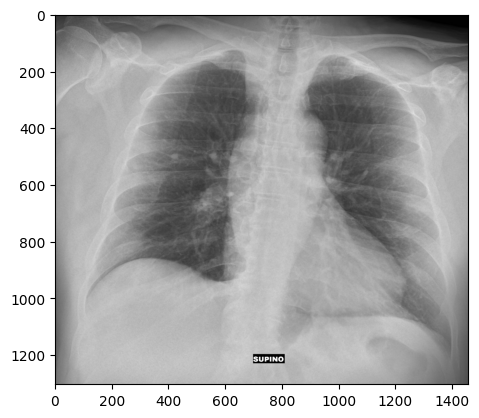

In [6]:
# covid_image
import numpy as np
import matplotlib.pyplot as plt
covid_image = plt.imread(training_data_path+"/Covid/"+"010.png")

plt.imshow(covid_image)
plt.show()

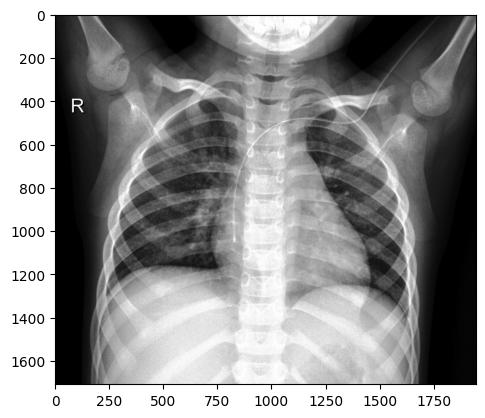

In [7]:
# Normal Image
import numpy as np
import matplotlib.pyplot as plt
Normal_Image  = plt.imread(training_data_path+"/Normal/"+"01.jpeg")

plt.imshow(Normal_Image)
plt.show()

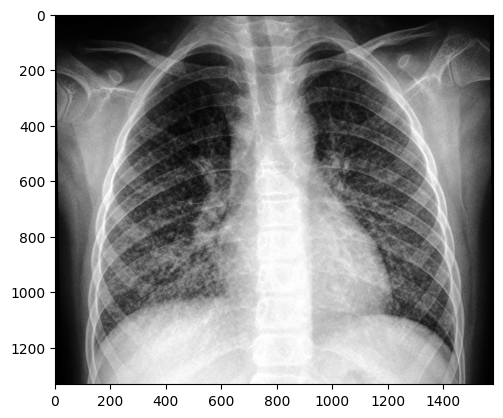

In [8]:
# Pnemonia
Pnemonia_image = plt.imread(training_data_path+"/Viral Pneumonia"+"/01.jpeg")
plt.imshow(Pnemonia_image)
plt.show()

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
train_data_preprocessing = ImageDataGenerator(1 / 255,
                                              rotation_range=0.2,
                                              shear_range=0.2,
                                              horizontal_flip=True)

val_data_preprocessing = ImageDataGenerator(1 / 255,
                                              rotation_range=0.2,
                                              shear_range=0.2,
                                              horizontal_flip=True)


In [11]:
final_train_data = train_data_preprocessing.flow_from_directory(training_data_path,
                                             target_size=(256, 256),
                                             class_mode='categorical',
                                             classes = labels,
                                             batch_size = 20)


final_val_data = val_data_preprocessing.flow_from_directory(validation_data_path,
                                             target_size=(256, 256),
                                             class_mode='categorical',
                                             classes = labels)


Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [12]:
# Architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Activation
from tensorflow.keras.activations import relu,sigmoid,softmax


model = Sequential()

# 1st Hidden layer
model.add(Conv2D(filters=64 , kernel_size=(3,3),padding="valid",kernel_initializer="he_uniform",
                 activation=relu,))
model.add(MaxPool2D(pool_size=(2,2)))

# 2st Hidden layer
model.add(Conv2D(filters=16 , kernel_size=(3,3),padding="valid",kernel_initializer="he_uniform",
                 activation=relu,))
model.add(MaxPool2D(pool_size=(2,2)))

# 3rd Hidden layer
model.add(Conv2D(filters=4 , kernel_size=(3,3),padding="valid",kernel_initializer="he_uniform",
                 activation=relu,))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

# give to ann
model.add(Dense(units = 64 , kernel_initializer="he_uniform",activation=relu))
model.add(Dense(units = 16 , kernel_initializer="he_uniform",activation=relu))
model.add(Dense(units = 4 , kernel_initializer="he_uniform",activation=relu))

model.add(Dense(units = 3 , kernel_initializer="glorot_uniform",activation=softmax))

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam',loss = 'categorical_crossentropy',metrics=['accuracy'])

In [15]:
model.fit(final_train_data , validation_data=final_val_data,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.3506 - loss: 7.6710 - val_accuracy: 0.4545 - val_loss: 1.5078
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 801ms/step - accuracy: 0.4343 - loss: 1.0875 - val_accuracy: 0.5000 - val_loss: 1.1289
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 793ms/step - accuracy: 0.5578 - loss: 0.9601 - val_accuracy: 0.4242 - val_loss: 1.1203
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 731ms/step - accuracy: 0.6175 - loss: 0.9179 - val_accuracy: 0.5909 - val_loss: 1.2547
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 753ms/step - accuracy: 0.5976 - loss: 0.9108 - val_accuracy: 0.5455 - val_loss: 1.2092


# do prediction

In [16]:
import cv2

In [17]:
final_train_data.class_indices

{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}

In [18]:
def pred_image(path_of_image):
  image = cv2.imread(path_of_image,1) # original image
  resized_image = cv2.resize(image , (256,256)) # resizing
  scaled_pixel_values = resized_image / 255  # scaled pixel values
  input_image = np.expand_dims(scaled_pixel_values , axis=0)

  result = model.predict(input_image)
  print(labels[np.argmax(result)])

  plt.imshow(image[:,:,::-1])
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 925ms/step
Covid


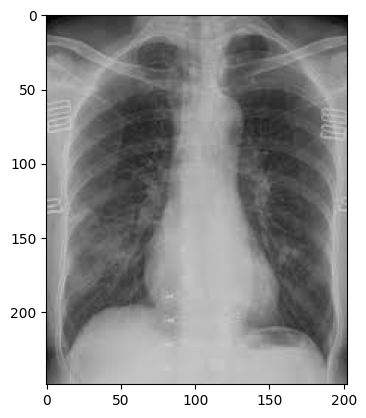

In [19]:
pred_image("/content/covid.jpg")